In [1]:
!pip -q install -U "numpy>=2.0.0"
!pip -q uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless trl transformers accelerate peft
!pip -q install -U opencv-python-headless
!pip -q install "trl==0.11.4" "transformers==4.44.2" "accelerate==0.33.0" "datasets==2.20.0" torch

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
accelerate 0.33.0 requires numpy<2.0.0,>=1.17, but you have numpy 2.4.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatibl

In [2]:
import os, time
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, pipeline, set_seed
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead, create_reference_model

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)

In [3]:
base_model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(base_model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = 'left' # Added to fix FutureWarning
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLMWithValueHead.from_pretrained(base_model_name).to(device)
ref_model = create_reference_model(model)

print("Loaded:", base_model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loaded: distilgpt2


In [6]:
reward_model_name = "lvwerra/distilbert-imdb"
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=reward_model_name,
    device=0 if device == "cuda" else -1,
    truncation=True,
    max_length=512,
    return_all_scores=True,
    function_to_apply="none",
)

def compute_rewards(text_list, scale=1.0):
    outs = sentiment_pipe(text_list, batch_size=16)
    rewards = []
    for o in outs:
        score_map = {d["label"].upper(): float(d["score"]) for d in o}

        pos = score_map.get("POSITIVE", score_map.get("LABEL_1"))
        neg = score_map.get("NEGATIVE", score_map.get("LABEL_0"))

        r = (pos - neg) * scale
        rewards.append(r)
    return rewards

print(compute_rewards(["I loved it!", "I hated it!"]))

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


[5.087319374084473, -2.949851393699646]


In [7]:
raw = load_dataset("imdb", split="train").shuffle(seed=42).select(range(2000))

def build_prompt(ex, max_chars=200):
    snippet = ex["text"].replace("\n", " ").strip()[:max_chars]
    prompt = (
        "Write a movie review in a clearly POSITIVE tone about the following content.\n"
        f"Content: {snippet}\n"
        "Positive Review:"
    )
    return {"prompt": prompt}

ds = raw.map(build_prompt, remove_columns=raw.column_names)

max_prompt_len = 256
def tokenize_fn(ex):
    out = tokenizer(ex["prompt"], truncation=True, max_length=max_prompt_len, padding=False)
    return out

ds = ds.map(tokenize_fn, remove_columns=["prompt"])
ds.set_format(type="torch")
print(ds[0].keys(), len(ds))

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'attention_mask']) 2000


In [8]:
ppo_config = PPOConfig(
    learning_rate=1e-6,
    batch_size=8,
    mini_batch_size=4,
    ppo_epochs=4,
    gradient_accumulation_steps=1,
    target_kl=0.2,
    seed=42,
)

def collator(data):
    return tokenizer.pad(data, padding=True, return_tensors="pt")

ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=model,
    ref_model=ref_model,
    tokenizer=tokenizer,
    dataset=ds,
    data_collator=collator,
)

print("PPOTrainer ready. Steps:", len(ppo_trainer.dataloader))

PPOTrainer ready. Steps: 250


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(


In [9]:
def generate_samples(prompts, max_new_tokens=80):
    model.eval()
    outs = []
    for p in prompts:
        inputs = tokenizer(p, return_tensors="pt", truncation=True, max_length=max_prompt_len).to(device)
        with torch.no_grad():
            gen = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_p=0.95,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
            )
        outs.append(tokenizer.decode(gen[0], skip_special_tokens=True))
    return outs

sample_prompts = [
    "Write a movie review in a clearly POSITIVE tone about the following content.\nContent: A story about a family overcoming hardships.\nPositive Review:",
    "Write a movie review in a clearly POSITIVE tone about the following content.\nContent: An action movie with a hero saving the city.\nPositive Review:",
]

before = generate_samples(sample_prompts)
before_r = compute_rewards(before)
for i,(t,r) in enumerate(zip(before,before_r),1):
    print("="*80)
    print(f"[BEFORE {i}] reward={r:+.4f}\n{t[:900]}")
print("mean before:", sum(before_r)/len(before_r))

[BEFORE 1] reward=+1.5854
Write a movie review in a clearly POSITIVE tone about the following content.
Content: A story about a family overcoming hardships.
Positive Review: This article addresses the topic of sexual abuse and a variety of topics, including sexual orientation, gender identity, and gender identity (FOC). It concludes that there is not a clear solution to this problem.
Introduction
A critical topic to consider is whether and how pornography affects our children's lives. To find out when a child's sexual desire can lead to a sexual relationship, our research in the
[BEFORE 2] reward=+3.9457
Write a movie review in a clearly POSITIVE tone about the following content.
Content: An action movie with a hero saving the city.
Positive Review: An action movie with a heroic hero saving the city.
Advantages: It doesn't necessarily end with anything.
Preliminary Review: An action movie with a hero saving the city.
Review: An action movie with a hero saving the city.
Award Rating: A 

In [20]:
import time
import torch
import numpy as np
from trl.core import LengthSampler

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)


output_min_length = 8
output_max_length = 24
output_length_sampler = LengthSampler(output_min_length, output_max_length)


generation_kwargs = dict(
    min_length=-1,
    do_sample=True,
    top_p=0.9,
    temperature=0.7,
    pad_token_id=tokenizer.eos_token_id,
)

REWARD_BS = 16
total_steps = 200
t0 = time.time()
model.train()

for step, batch in enumerate(ppo_trainer.dataloader):
    if step >= total_steps:
        break

    input_ids = batch["input_ids"].to(device)
    attn = batch["attention_mask"].to(device)
    query_tensors = [ids[mask.bool()] for ids, mask in zip(input_ids, attn)]

    gen_len = output_length_sampler()
    generation_kwargs["max_new_tokens"] = gen_len

    t_gen0 = time.time()
    outs = ppo_trainer.generate(query_tensors, **generation_kwargs)  # list[Tensor] or Tensor
    t_gen1 = time.time()

    if isinstance(outs, torch.Tensor):
        outs = [x for x in outs]

    response_tensors = []
    for out in outs:
        out = out.squeeze()
        resp = out[-gen_len:]
        response_tensors.append(resp)

    gen_texts = [tokenizer.decode(r, skip_special_tokens=True) for r in response_tensors]

    t_rw0 = time.time()
    rewards = compute_rewards(gen_texts)
    t_rw1 = time.time()

    rewards_tensors = [torch.tensor(float(r), device=device) for r in rewards]

    stats = ppo_trainer.step(query_tensors, response_tensors, rewards_tensors)

    mean_reward = float(np.mean(rewards))
    if step % 5 == 0:
        kl = get_kl(stats) if "get_kl" in globals() else None
        if kl is None:
            print(f"step={step:04d} mean_reward={mean_reward:+.4f} gen={t_gen1-t_gen0:.2f}s reward={t_rw1-t_rw0:.2f}s")
        else:
            print(f"step={step:04d} mean_reward={mean_reward:+.4f} kl={kl:+.4f} gen={t_gen1-t_gen0:.2f}s reward={t_rw1-t_rw0:.2f}s")

print("done, time:", round(time.time() - t0, 1), "s")

step=0000 mean_reward=+3.5558 gen=0.69s reward=0.02s


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.14 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


step=0005 mean_reward=+1.8668 gen=0.18s reward=0.01s


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.36 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -4.98 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


step=0010 mean_reward=+1.3012 gen=0.26s reward=0.01s
step=0015 mean_reward=+1.0821 gen=0.23s reward=0.01s
step=0020 mean_reward=+3.2906 gen=0.22s reward=0.01s


...

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.23 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -3.09 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


step=0190 mean_reward=+4.7555 gen=0.24s reward=0.01s


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -2.88 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


step=0195 mean_reward=+3.8009 gen=0.14s reward=0.01s
done, time: 247.4 s


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -5.48 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


In [21]:
after = generate_samples(sample_prompts)
after_r = compute_rewards(after)
for i,(t,r) in enumerate(zip(after,after_r),1):
    print("="*80)
    print(f"[AFTER {i}] reward={r:+.4f}\n{t[:900]}")

print("mean before:", sum(before_r)/len(before_r))
print("mean after :", sum(after_r)/len(after_r))

[AFTER 1] reward=+3.5431
Write a movie review in a clearly POSITIVE tone about the following content.
Content: A story about a family overcoming hardships.
Positive Review: I know I‪ll be playing with this book in The Walking Dead. This book is very enjoyable. It‭d not be the worst-ass story that‬s written. You really can‬t get enough enjoyment with that. The characters are engaging and have a good feel for them.
Good Read: The story doesn‏t have a bad ending, it doesn
[AFTER 2] reward=+3.5117
Write a movie review in a clearly POSITIVE tone about the following content.
Content: An action movie with a hero saving the city.
Positive Review: What about the next movie I will talk about, and what to expect of a movie that I will discuss.
Advertisements
mean before: 2.7655449211597443
mean after : 3.527400493621826


In [22]:
save_dir = "rlhf_positive_gpt2_trl"
os.makedirs(save_dir, exist_ok=True)
ppo_trainer.model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print("Saved:", save_dir)

Saved: rlhf_positive_gpt2_trl


In [23]:
import torch
import numpy as np
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
ref_model = ref_model.to(device)

def build_prompt(text, max_chars=200):
    snippet = text.replace("\n", " ").strip()[:max_chars]
    return (
        "Write a movie review in a clearly POSITIVE tone about the following content.\n"
        f"Content: {snippet}\n"
        "Positive Review:"
    )


EVAL_N = 200
test_ds = load_dataset("imdb", split="test").shuffle(seed=123).select(range(EVAL_N))
eval_prompts = [build_prompt(t) for t in test_ds["text"]]

@torch.no_grad()
def generate_from(model_obj, prompts, max_prompt_len=256, max_new_tokens=80, batch_size=8):
    model_obj.eval()
    outputs = []
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i+batch_size]
        enc = tokenizer(
            batch_prompts,
            return_tensors="pt",
            truncation=True,
            max_length=max_prompt_len,
            padding=True,
        ).to(device)

        gen = model_obj.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_p=0.95,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
        outputs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
    return outputs


baseline_texts = generate_from(ref_model, eval_prompts, max_new_tokens=80, batch_size=8)

trained_texts  = generate_from(model, eval_prompts, max_new_tokens=80, batch_size=8)


baseline_rewards = np.array(compute_rewards(baseline_texts), dtype=np.float32)
trained_rewards  = np.array(compute_rewards(trained_texts), dtype=np.float32)

delta = trained_rewards - baseline_rewards

print("Eval size:", len(eval_prompts))
print("Baseline mean reward:", float(baseline_rewards.mean()))
print("Trained   mean reward:", float(trained_rewards.mean()))
print("Mean delta (trained - baseline):", float(delta.mean()))

Eval size: 200
Baseline mean reward: 1.6248849630355835
Trained   mean reward: 3.883496046066284
Mean delta (trained - baseline): 2.258610963821411


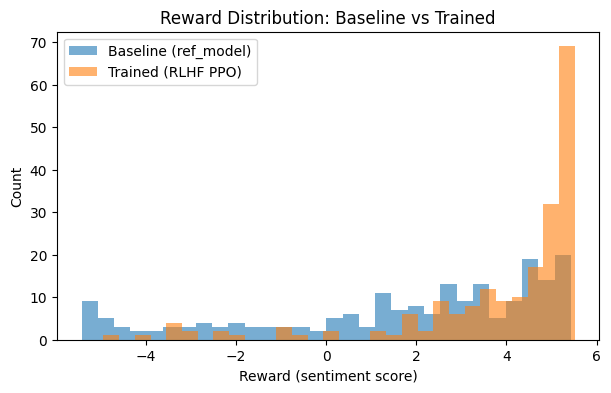

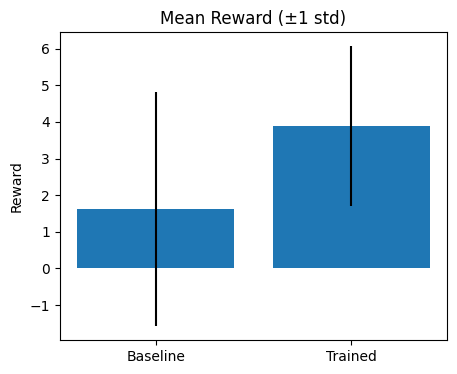

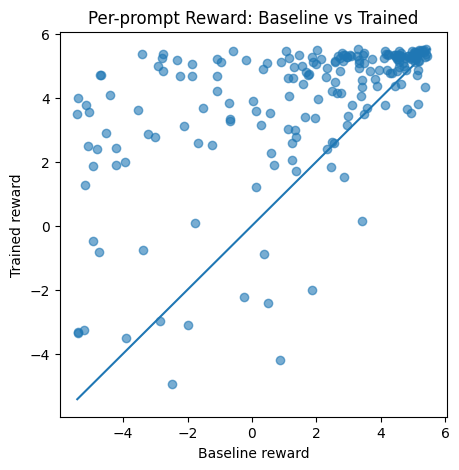

In [24]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(7,4))
plt.hist(baseline_rewards, bins=30, alpha=0.6, label="Baseline (ref_model)")
plt.hist(trained_rewards,  bins=30, alpha=0.6, label="Trained (RLHF PPO)")
plt.xlabel("Reward (sentiment score)")
plt.ylabel("Count")
plt.title("Reward Distribution: Baseline vs Trained")
plt.legend()
plt.show()


means = [baseline_rewards.mean(), trained_rewards.mean()]
stds  = [baseline_rewards.std(),  trained_rewards.std()]

plt.figure(figsize=(5,4))
plt.bar(["Baseline", "Trained"], means, yerr=stds)
plt.ylabel("Reward")
plt.title("Mean Reward (±1 std)")
plt.show()


plt.figure(figsize=(5,5))
plt.scatter(baseline_rewards, trained_rewards, alpha=0.6)
mn = float(min(baseline_rewards.min(), trained_rewards.min()))
mx = float(max(baseline_rewards.max(), trained_rewards.max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Baseline reward")
plt.ylabel("Trained reward")
plt.title("Per-prompt Reward: Baseline vs Trained")
plt.show()



In [25]:
import numpy as np
import textwrap

top_k = 5
top_idx = np.argsort(-delta)[:top_k]

for rank, idx in enumerate(top_idx, 1):
    prompt_snip = eval_prompts[idx].split("Content:",1)[-1].split("\nPositive Review:",1)[0].strip()

    print("="*100)
    print(f"[TOP IMPROVEMENT #{rank}] idx={idx}")
    print(f"Baseline reward: {baseline_rewards[idx]:+.4f}")
    print(f"Trained  reward: {trained_rewards[idx]:+.4f}")
    print(f"Delta          : {delta[idx]:+.4f}")
    print("-"*100)
    print("PROMPT (content snippet):")
    print(textwrap.fill(prompt_snip[:300], width=100))
    print("-"*100)
    print("BASELINE OUTPUT:")
    print(baseline_texts[idx][:1000])
    print("-"*100)
    print("TRAINED OUTPUT:")
    print(trained_texts[idx][:1000])

[TOP IMPROVEMENT #1] idx=12
Baseline reward: -4.7279
Trained  reward: +4.6978
Delta          : +9.4257
----------------------------------------------------------------------------------------------------
PROMPT (content snippet):
<br /><br />In the process of boring you with the wordy, rambling storyline and the complete absence
of character development, it manages to enforce a few negative black stereotypes out there. At one
----------------------------------------------------------------------------------------------------
BASELINE OUTPUT:
Write a movie review in a clearly POSITIVE tone about the following content.
Content: <br /><br />In the process of boring you with the wordy, rambling storyline and the complete absence of character development, it manages to enforce a few negative black stereotypes out there. At one 
Positive Review: <br /><br />When I was 10 years old my mother was really dumb and I was very afraid. We talked about the movie so my mother wanted to go and watch t

In [26]:
model.save_pretrained("ppo_positive_imdb")
tokenizer.save_pretrained("ppo_positive_imdb")

('ppo_positive_imdb/tokenizer_config.json',
 'ppo_positive_imdb/special_tokens_map.json',
 'ppo_positive_imdb/vocab.json',
 'ppo_positive_imdb/merges.txt',
 'ppo_positive_imdb/added_tokens.json',
 'ppo_positive_imdb/tokenizer.json')